In [1]:
# ## 1. Импорты, seed и среда

# %%
import math
import random
import json
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Настройки
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)

# Создаём папки для артефактов
Path("artifacts/figures").mkdir(parents=True, exist_ok=True)

# Фиксируем seed для воспроизводимости
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


Размер датасета: 4320 наблюдений
Диапазон дат: 2025-01-01 00:00:00 → 2025-06-29 23:00:00
Пропуски:
date      0
target    0
dtype: int64


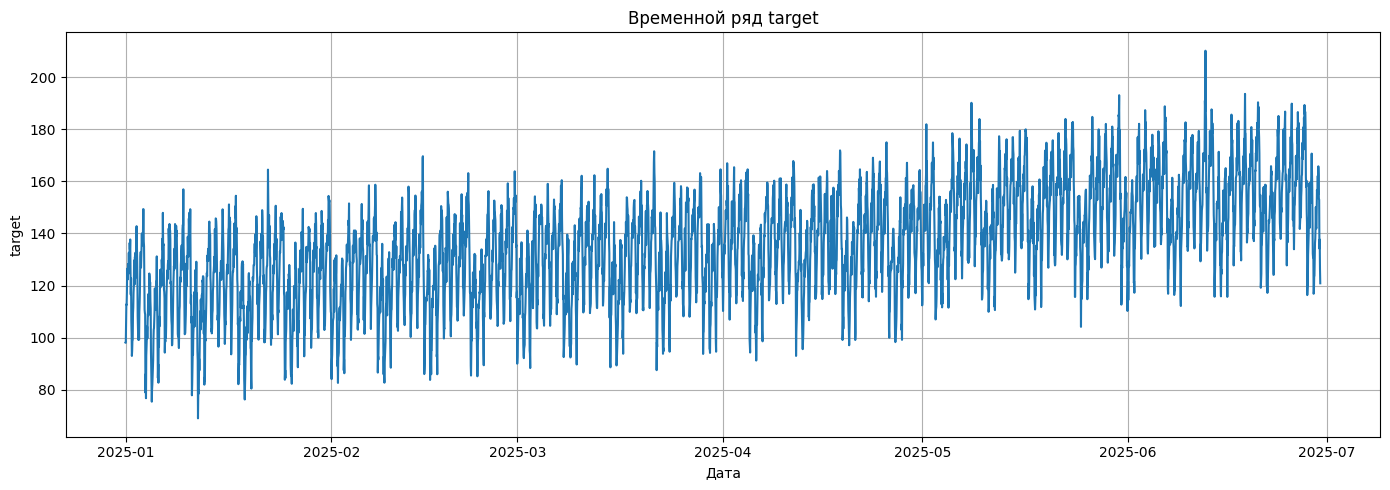


Анализ ряда:
- Видна выраженная суточная сезонность (дневные пики, ночные спады)
- Присутствуют выбросы и аномальные всплески
- Тренд незначительный
- Пропусков нет


In [3]:
df = pd.read_csv("S12-hw-dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Размер датасета: {len(df)} наблюдений")
print(f"Диапазон дат: {df['date'].min()} → {df['date'].max()}")
print(f"Пропуски:\n{df.isnull().sum()}")

# Базовый график
fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], lw=1.5)
ax.set_title("Временной ряд target")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
plt.tight_layout()
plt.savefig("artifacts/figures/series_original.png", dpi=150)
plt.show()

# Комментарий
print("\nАнализ ряда:")
print("- Видна выраженная суточная сезонность (дневные пики, ночные спады)")
print("- Присутствуют выбросы и аномальные всплески")
print("- Тренд незначительный")
print("- Пропусков нет")

Train: 3024 наблюдений, 2025-01-01 00:00:00 → 2025-05-06 23:00:00
Val:   648 наблюдений, 2025-05-07 00:00:00 → 2025-06-02 23:00:00
Test:  648 наблюдений, 2025-06-03 00:00:00 → 2025-06-29 23:00:00


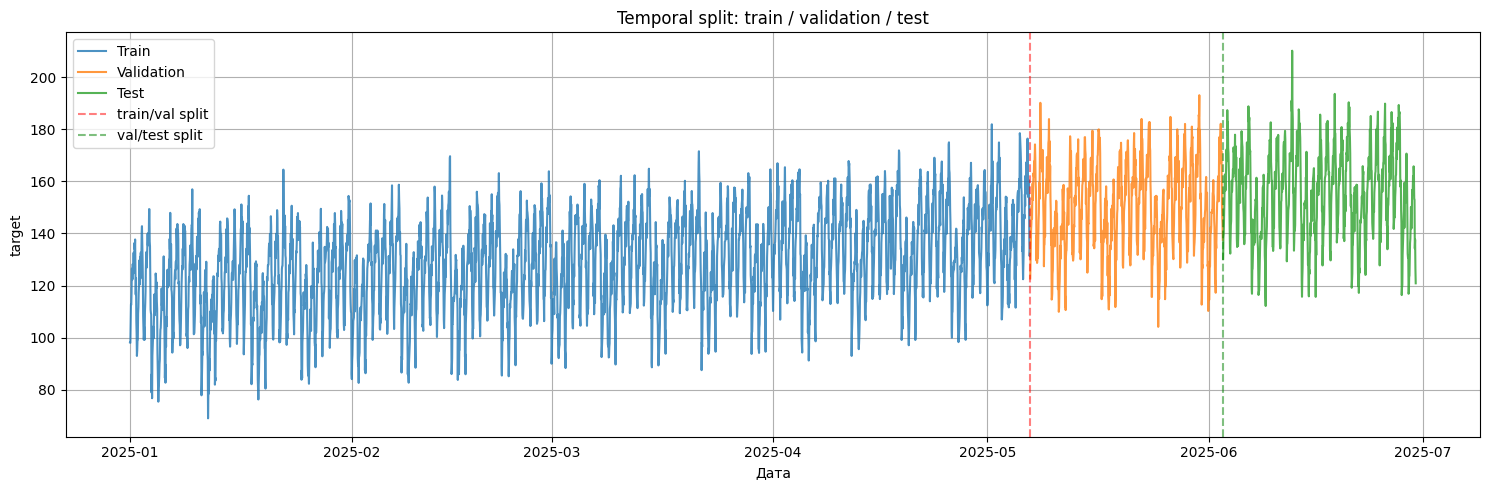


Почему random split некорректен?
Random split нарушает временную структуру, позволяя модели 'подглядывать' в будущее.
Для прогнозирования важно, чтобы модель училась на прошлом и проверялась на будущем.


In [4]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))
    
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"Train: {len(train_df)} наблюдений, {train_df['date'].min()} → {train_df['date'].max()}")
print(f"Val:   {len(val_df)} наблюдений, {val_df['date'].min()} → {val_df['date'].max()}")
print(f"Test:  {len(test_df)} наблюдений, {test_df['date'].min()} → {test_df['date'].max()}")

# Визуализация split
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_df["date"], train_df["target"], label="Train", alpha=0.8)
ax.plot(val_df["date"], val_df["target"], label="Validation", alpha=0.8)
ax.plot(test_df["date"], test_df["target"], label="Test", alpha=0.8)
ax.axvline(x=train_df["date"].iloc[-1], color='red', linestyle='--', alpha=0.5, label='train/val split')
ax.axvline(x=val_df["date"].iloc[-1], color='green', linestyle='--', alpha=0.5, label='val/test split')
ax.set_title("Temporal split: train / validation / test")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/series_split.png", dpi=150)
plt.show()

print("\nПочему random split некорректен?")
print("Random split нарушает временную структуру, позволяя модели 'подглядывать' в будущее.")
print("Для прогнозирования важно, чтобы модель училась на прошлом и проверялась на будущем.")

In [5]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["hour"] = out["date"].dt.hour
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month
    # Синус/косинус для цикличности
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)
    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()
    # Лаги
    for lag in [1, 2, 3, 7, 14, 24, 48]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)
    # Rolling-статистики (только из прошлого)
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    out["rolling_mean_24"] = out[target_col].shift(1).rolling(window=24).mean()
    out["rolling_std_24"] = out[target_col].shift(1).rolling(window=24).std()
    return out

# Построение признаков
features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)

# Удаляем строки с NaN (из-за лагов)
features_df = features_df.dropna().reset_index(drop=True)
print(f"После построения признаков: {len(features_df)} строк")

# Повторяем temporal split
train_feat, val_feat, test_feat = temporal_split(features_df)

# Определяем признаки
feature_cols = [
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_24", "lag_48",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_24", "rolling_std_24"
]
target_col = "target"

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]
X_val = val_feat[feature_cols]
y_val = val_feat[target_col]
X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")


После построения признаков: 4272 строк
X_train: (2990, 15), y_train: (2990,)
X_val:   (641, 15), y_val:   (641,)
X_test:  (641, 15), y_test:  (641,)


In [6]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str):
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }

# B1: naive baseline (прогноз = последнее значение)
b1_val_pred = val_feat["lag_1"].to_numpy()
b1_test_pred = test_feat["lag_1"].to_numpy()

b1_val_metrics = evaluate_regression(y_val, b1_val_pred, "B1: Naive (lag_1)")
b1_test_metrics = evaluate_regression(y_test, b1_test_pred, "B1: Naive (lag_1)")


# %% [markdown]
# ## 6. Эксперимент B2: Moving Average

# %%
# B2: скользящее среднее за 24 часа
b2_val_pred = val_feat["rolling_mean_24"].to_numpy()
b2_test_pred = test_feat["rolling_mean_24"].to_numpy()

b2_val_metrics = evaluate_regression(y_val, b2_val_pred, "B2: Moving Average (24h)")
b2_test_metrics = evaluate_regression(y_test, b2_test_pred, "B2: Moving Average (24h)")

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Обучение Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

b3_val_pred = ridge.predict(X_val_scaled)
b3_test_pred = ridge.predict(X_test_scaled)

b3_val_metrics = evaluate_regression(y_val, b3_val_pred, "B3: Ridge + lag features")
b3_test_metrics = evaluate_regression(y_test, b3_test_pred, "B3: Ridge + lag features")

In [8]:
# Масштабирование для GRU (только по train)
scaler_gru = StandardScaler()
train_scaled = scaler_gru.fit_transform(train_df[["target"]]).astype(np.float32)
val_scaled = scaler_gru.transform(val_df[["target"]]).astype(np.float32)
test_scaled = scaler_gru.transform(test_df[["target"]]).astype(np.float32)

window_size = 48  # 2 дня (48 часов)

def make_windows(series_2d: np.ndarray, window_size: int):
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i:i + window_size])
        y.append(series_2d[i + window_size, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train_w, y_train_w = make_windows(train_scaled, window_size)
X_val_w, y_val_w = make_windows(val_scaled, window_size)
X_test_w, y_test_w = make_windows(test_scaled, window_size)

print(f"X_train_w: {X_train_w.shape}, y_train_w: {y_train_w.shape}")
print(f"X_val_w:   {X_val_w.shape}, y_val_w:   {y_val_w.shape}")
print(f"X_test_w:  {X_test_w.shape}, y_test_w:  {y_test_w.shape}")

# Dataset и DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64
train_ds = TimeSeriesDataset(X_train_w, y_train_w)
val_ds = TimeSeriesDataset(X_val_w, y_val_w)
test_ds = TimeSeriesDataset(X_test_w, y_test_w)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

X_train_w: (2976, 48, 1), y_train_w: (2976,)
X_val_w:   (600, 48, 1), y_val_w:   (600,)
X_test_w:  (600, 48, 1), y_test_w:  (600,)


In [9]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred


# %% [markdown]
# ## 10. Функции обучения и оценки

# %%
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)

def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()
    preds, targets = [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()
        preds.append(outputs)
        targets.append(y_batch.numpy())
    return np.concatenate(preds), np.concatenate(targets)

def inverse_scale(values, scaler):
    return scaler.inverse_transform(values.reshape(-1, 1)).ravel()

GRU params: 37889
Epoch 01 | train_loss=0.7106 | val_loss=0.6418
Epoch 05 | train_loss=0.1503 | val_loss=0.2292
Epoch 10 | train_loss=0.1446 | val_loss=0.2028
Epoch 15 | train_loss=0.1320 | val_loss=0.2161
Epoch 20 | train_loss=0.1007 | val_loss=0.1388
Epoch 25 | train_loss=0.0952 | val_loss=0.1298
Epoch 30 | train_loss=0.0939 | val_loss=0.1441


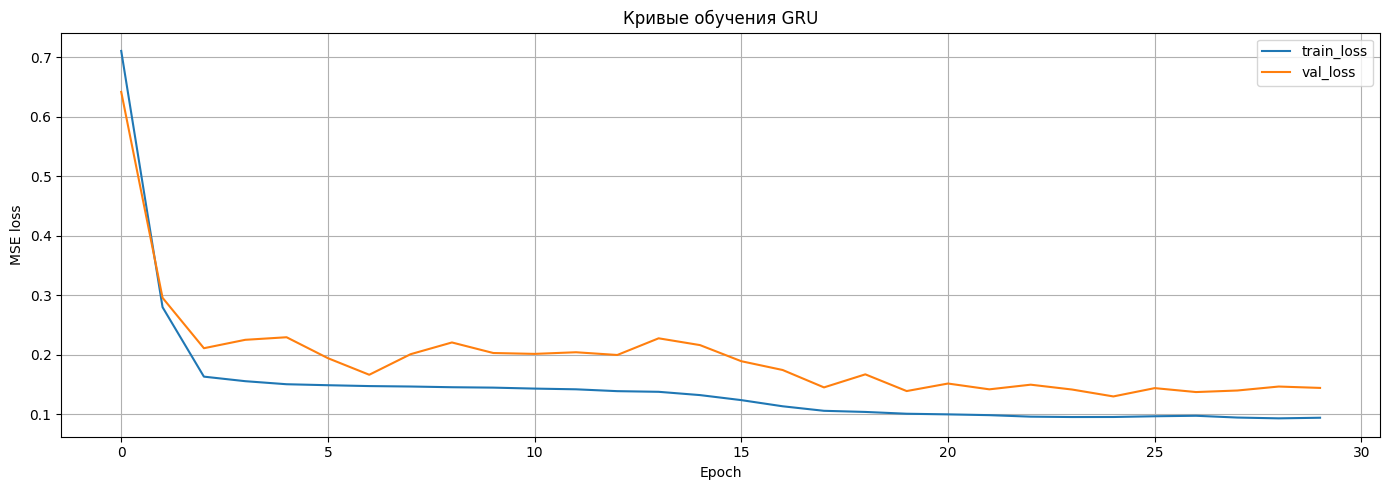

In [10]:
set_seed(42)
model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print(f"GRU params: {sum(p.numel() for p in model.parameters())}")

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

num_epochs = 30
best_val_loss = float("inf")
best_state = None
history = {"train_loss": [], "val_loss": []}

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate_loss(model, val_loader, criterion, device)
    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict().copy()
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

# Восстанавливаем лучшую модель
model.load_state_dict(best_state)

# Сохраняем модель и конфиг
torch.save(model.state_dict(), "artifacts/best_gru.pt")
config = {
    "model_type": "GRUForecaster",
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "window_size": window_size,
    "batch_size": batch_size,
    "learning_rate": 5e-4,
    "num_epochs": num_epochs,
    "seed": 42,
    "scaler_mean": scaler_gru.mean_[0],
    "scaler_scale": scaler_gru.scale_[0],
}
with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(config, f, indent=2)

# Кривые обучения
fig, ax = plt.subplots()
ax.plot(history["train_loss"], label="train_loss")
ax.plot(history["val_loss"], label="val_loss")
ax.set_title("Кривые обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/gru_learning_curves.png", dpi=150)
plt.show()


In [11]:
# Предсказания на валидации и тесте
gru_val_pred_scaled, gru_val_true_scaled = predict_model(model, val_loader, device)
gru_test_pred_scaled, gru_test_true_scaled = predict_model(model, test_loader, device)

# Возвращаем в исходный масштаб
gru_val_true = inverse_scale(gru_val_true_scaled, scaler_gru)
gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler_gru)
gru_test_true = inverse_scale(gru_test_true_scaled, scaler_gru)
gru_test_pred = inverse_scale(gru_test_pred_scaled, scaler_gru)

# Метрики
gru_val_metrics = evaluate_regression(gru_val_true, gru_val_pred, "R1: GRU")
gru_test_metrics = evaluate_regression(gru_test_true, gru_test_pred, "R1: GRU")


# %% [markdown]
# ## 13. Сбор всех результатов в runs.csv

# %%
# Собираем все метрики
all_results = [
    {**b1_val_metrics, "dataset": "S12-hw-dataset", "split": "validation"},
    {**b2_val_metrics, "dataset": "S12-hw-dataset", "split": "validation"},
    {**b3_val_metrics, "dataset": "S12-hw-dataset", "split": "validation"},
    {**gru_val_metrics, "dataset": "S12-hw-dataset", "split": "validation"},
    {**b1_test_metrics, "dataset": "S12-hw-dataset", "split": "test"},
    {**b2_test_metrics, "dataset": "S12-hw-dataset", "split": "test"},
    {**b3_test_metrics, "dataset": "S12-hw-dataset", "split": "test"},
    {**gru_test_metrics, "dataset": "S12-hw-dataset", "split": "test"},
]

runs_df = pd.DataFrame(all_results)
runs_df.to_csv("artifacts/runs.csv", index=False)
print("Результаты сохранены в artifacts/runs.csv")
display(runs_df)

Результаты сохранены в artifacts/runs.csv


,model,MAE,RMSE,MAPE_%,dataset,split
0,B1: Naive (lag_1),6.452590,8.220913,4.402828,S12-hw-dataset,validation
1,B2: Moving Average (24h),13.452306,16.224265,9.237375,S12-hw-dataset,validation
2,B3: Ridge + lag features,5.123285,6.601584,3.474162,S12-hw-dataset,validation
3,R1: GRU,5.475151,7.014912,3.667393,S12-hw-dataset,validation
4,B1: Naive (lag_1),6.349813,8.077851,4.151242,S12-hw-dataset,test
5,B2: Moving Average (24h),13.140068,16.116005,8.730875,S12-hw-dataset,test
6,B3: Ridge + lag features,5.045399,6.512850,3.290601,S12-hw-dataset,test
7,R1: GRU,6.554375,8.263806,4.189631,S12-hw-dataset,test


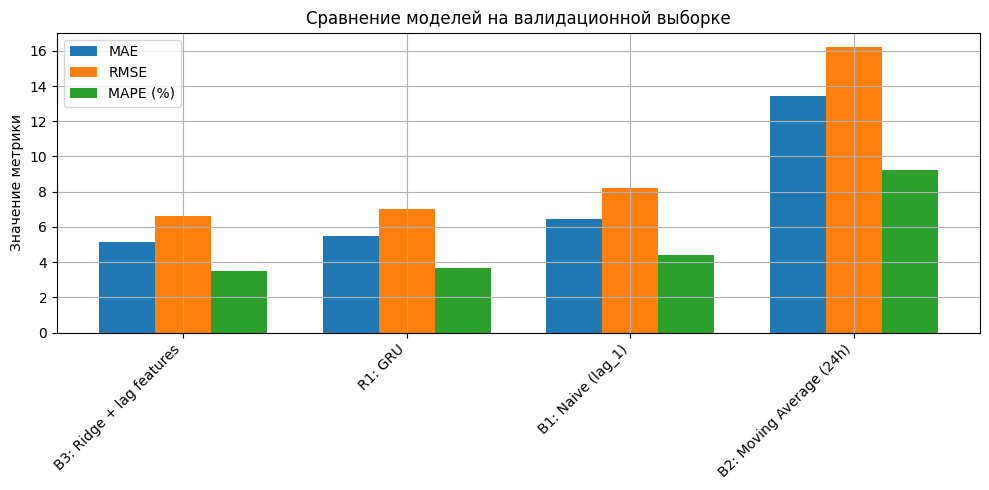


Лучшая модель на валидации по MAE: B3: Ridge + lag features


In [12]:
# Сравнение по MAE на валидации
val_comparison = runs_df[runs_df["split"] == "validation"].copy()
val_comparison = val_comparison.sort_values("MAE")

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(val_comparison))
width = 0.25

ax.bar(x - width, val_comparison["MAE"], width, label="MAE")
ax.bar(x, val_comparison["RMSE"], width, label="RMSE")
ax.bar(x + width, val_comparison["MAPE_%"], width, label="MAPE (%)")

ax.set_xticks(x)
ax.set_xticklabels(val_comparison["model"], rotation=45, ha="right")
ax.set_title("Сравнение моделей на валидационной выборке")
ax.set_ylabel("Значение метрики")
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/baselines_compare.png", dpi=150)
plt.show()

print("\nЛучшая модель на валидации по MAE:", val_comparison.iloc[0]["model"])

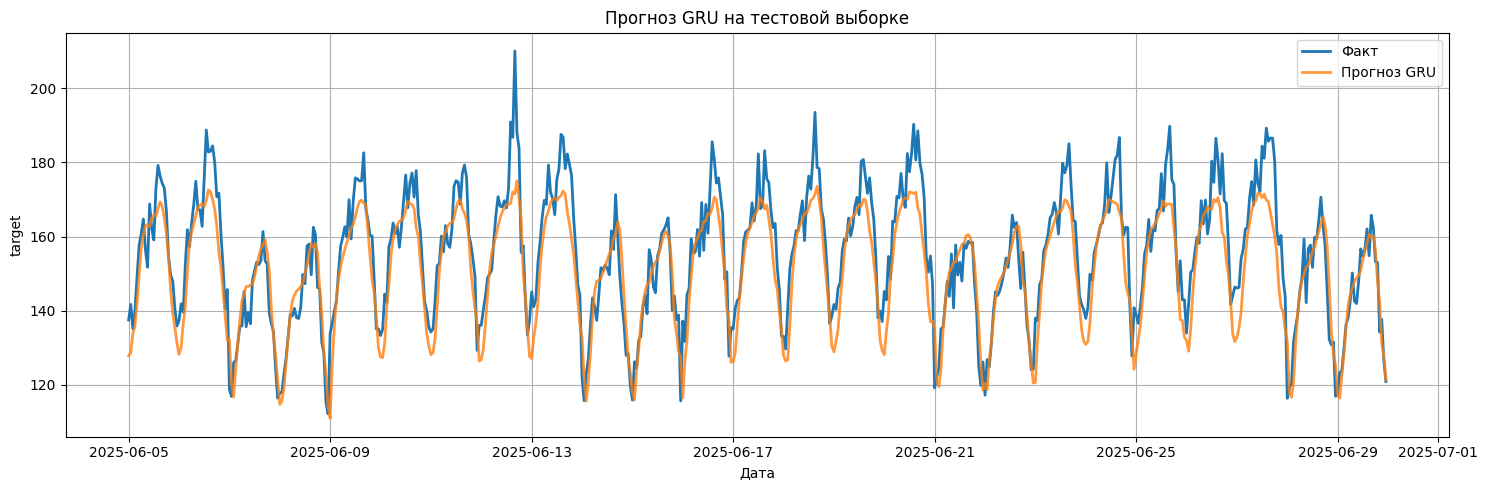

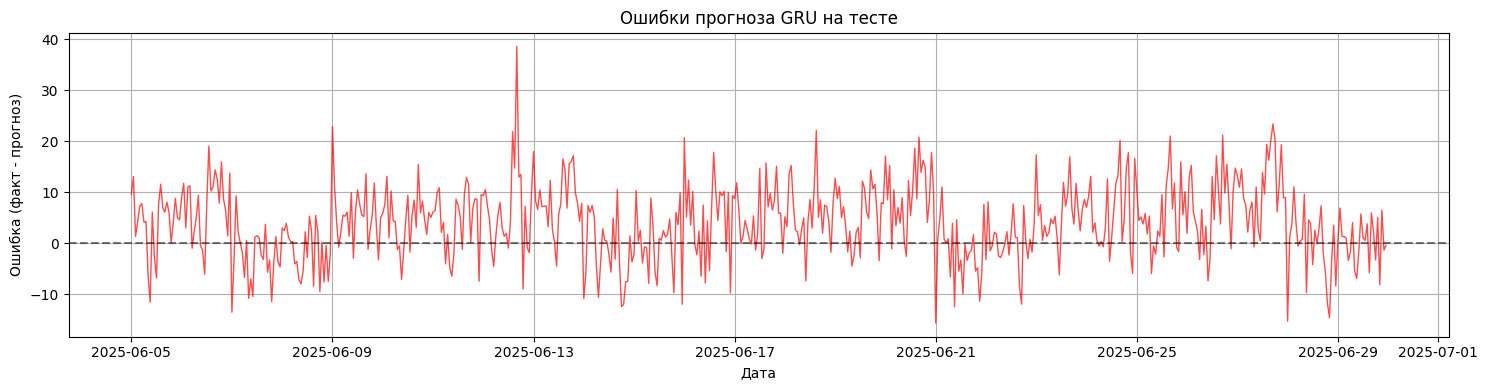


Финальные метрики лучшей модели (GRU) на тесте:
MAE:  6.5544
RMSE: 8.2638
MAPE: 4.19%


In [13]:
# График прогноза лучшей модели на тесте
test_dates = test_df["date"].iloc[window_size:].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(test_dates, gru_test_true, label="Факт", lw=2)
ax.plot(test_dates, gru_test_pred, label="Прогноз GRU", lw=2, alpha=0.8)
ax.set_title("Прогноз GRU на тестовой выборке")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/best_forecast_test.png", dpi=150)
plt.show()

# Ошибки
errors = gru_test_true - gru_test_pred
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(test_dates, errors, lw=1, color="red", alpha=0.7)
ax.axhline(y=0, color="black", linestyle="--", alpha=0.5)
ax.set_title("Ошибки прогноза GRU на тесте")
ax.set_xlabel("Дата")
ax.set_ylabel("Ошибка (факт - прогноз)")
plt.tight_layout()
plt.savefig("artifacts/figures/residuals_best.png", dpi=150)
plt.show()

print("\nФинальные метрики лучшей модели (GRU) на тесте:")
print(f"MAE:  {gru_test_metrics['MAE']:.4f}")
print(f"RMSE: {gru_test_metrics['RMSE']:.4f}")
print(f"MAPE: {gru_test_metrics['MAPE_%']:.2f}%")